# Part 4 — Python Data Cleaning & Validation

This notebook cleans `orders_raw.csv`, validates it against the Part 1 SQL findings, and produces summary charts and insights.

**Sections:**
1. Load raw data
2. Task 2 — Deduplication & shape check (expect exactly 500 rows remaining)
3. Task 3 — Standardize categorical fields (`city`, `category`)
4. Task 4 — Handle missing values (documented, not blanket-filled)
5. Task 5 — IQR outlier detection on Delivered orders, capped via `.clip()`
6. Task 6 — Cross-validation against Part 1 SQL (top category, top supplier via merge)
7. Charts (3 matplotlib visualizations)
8. Insights (3 What / Why / Next-step observations)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load raw data

In [27]:
df_raw = pd.read_csv("orders_raw.csv")
print("Raw shape:", df_raw.shape)
print("More than 500 rows in the raw export:", len(df_raw) > 500)
df_raw.head()

Raw shape: (508, 11)
More than 500 rows in the raw export: True


,order_id,order_date,customer_name,city,category,product_id,quantity,amount_inr,payment_mode,status,rating
0,1,2026-03-09,Dev,Pune,Snacks & Beverages,13,5,175.0,UPI,Delivered,5.0
1,2,2026-05-22,Ayaan,Bengaluru,Snacks & Beverages,15,1,60.0,Debit Card,Delivered,5.0
2,3,2026-06-30,Yash,Bengaluru,Household Essentials,25,2,150.0,UPI,Delivered,2.0
3,4,2026-03-01,Sneha,Hyderabad,Snacks & Beverages,11,1,30.0,UPI,Delivered,4.0
4,5,2026-04-05,Rohit,Mumbai,Snacks & Beverages,14,2,220.0,Debit Card,Delivered,3.0


## 2. Task 2 — Remove duplicate rows

We drop exact duplicate rows. The acceptance criterion is that **exactly 500 rows remain** after this step.

In [28]:
before = len(df_raw)
df = df_raw.drop_duplicates().copy()
after = len(df)

print(f"Rows before dedup: {before}")
print(f"Duplicate rows removed: {before - after}")
print(f"Rows after dedup: {after}")
assert after == 500, f"Expected exactly 500 rows after dedup, got {after}"
print("PASS: exactly 500 rows remain, matching the Task 2 acceptance criterion.")

Rows before dedup: 508
Duplicate rows removed: 8
Rows after dedup: 500
PASS: exactly 500 rows remain, matching the Task 2 acceptance criterion.


## 3. Task 3 — Standardize categorical fields

`city` and `category` have inconsistent casing/whitespace in the raw export. We normalize both to Title Case and strip whitespace, then confirm the canonical counts: **4 distinct cities, 6 distinct categories** — matching Parts 1–3.

In [29]:
df['city'] = df['city'].str.strip().str.title()
df['category'] = df['category'].str.strip().str.title()
df['status'] = df['status'].str.strip().str.title()

n_cities = df['city'].nunique()
n_categories = df['category'].nunique()

print("Distinct cities:", n_cities, "->", sorted(df['city'].unique()))
print("Distinct categories:", n_categories, "->", sorted(df['category'].unique()))

assert n_cities == 4, f"Expected 4 distinct cities, got {n_cities}"
assert n_categories == 6, f"Expected 6 distinct categories, got {n_categories}"
print("PASS: 4 cities and 6 categories match the canonical lists used in Parts 1-3.")

Distinct cities: 4 -> ['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']
Distinct categories: 6 -> ['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']
PASS: 4 cities and 6 categories match the canonical lists used in Parts 1-3.


## 4. Task 4 — Handle missing values (documented, not blindly filled)

- **`amount_inr`**: rows with a missing amount cannot be assigned a revenue figure without guessing, so they are **counted and excluded from revenue sums** — not filled with a mean/median, which would distort totals.
- **`rating`**: orders with status `Cancelled` or `Pending` were never completed, so a missing rating on those rows is expected and is **left unfilled deliberately** (a Cancelled order was never rated — filling it would fabricate data). Missing ratings on `Delivered` orders are filled with the median Delivered rating, since a completed order should have a rating.

In [30]:
print("Null counts before handling:")
print(df.isnull().sum())

missing_amount_count = df['amount_inr'].isnull().sum()
print(f"\nRows with missing amount_inr (excluded from revenue sums): {missing_amount_count}")

# Rating: only fill for Delivered orders; leave Cancelled/Pending nulls as-is (documented reason above)
delivered_median_rating = df.loc[df['status'] == 'Delivered', 'rating'].median()
mask_fillable = (df['status'] == 'Delivered') & (df['rating'].isnull())
df.loc[mask_fillable, 'rating'] = delivered_median_rating

still_null_rating = df['rating'].isnull().sum()
print(f"Delivered-order rating nulls filled with median ({delivered_median_rating}).")
print(f"Remaining null ratings (Cancelled/Pending, left unfilled by design): {still_null_rating}")

print("\nNull counts after handling:")
print(df.isnull().sum())

Null counts before handling:
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           66
dtype: int64

Rows with missing amount_inr (excluded from revenue sums): 10
Delivered-order rating nulls filled with median (3.0).
Remaining null ratings (Cancelled/Pending, left unfilled by design): 66

Null counts after handling:
order_id          0
order_date        0
customer_name     0
city              0
category          0
product_id        0
quantity          0
amount_inr       10
payment_mode      0
status            0
rating           66
dtype: int64


## 5. Task 5 — IQR outlier detection on Delivered orders

Outlier bounds (Q1, Q3, IQR, upper fence) are computed **only on `Delivered` orders with a non-null `amount_inr`** — Cancelled/Pending orders and missing amounts would distort the quartiles. Rather than dropping outliers (which would delete real transactions), values above the upper fence are **capped via `.clip()`**, preserving row count.

In [31]:
delivered_amounts = df.loc[(df['status'] == 'Delivered') & (df['amount_inr'].notnull()), 'amount_inr']

Q1 = delivered_amounts.quantile(0.25)
Q3 = delivered_amounts.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

n_outliers_above = (delivered_amounts > upper_fence).sum()

print(f"Q1 (Delivered, non-null amount_inr): {Q1}")
print(f"Q3 (Delivered, non-null amount_inr): {Q3}")
print(f"IQR: {IQR}")
print(f"Upper fence: {upper_fence}")
print(f"Lower fence: {lower_fence}")
print(f"Delivered orders above the upper fence (to be capped): {n_outliers_above}")

# Cap (clip) rather than drop -- row count is preserved
df['amount_inr_capped'] = df['amount_inr'].clip(upper=upper_fence)

print(f"\nRow count before capping: {len(df)}")
print(f"Row count after capping:  {len(df)} (unchanged -- capping, not dropping)")

Q1 (Delivered, non-null amount_inr): 90.0
Q3 (Delivered, non-null amount_inr): 275.0
IQR: 185.0
Upper fence: 552.5
Lower fence: -187.5
Delivered orders above the upper fence (to be capped): 16

Row count before capping: 500
Row count after capping:  500 (unchanged -- capping, not dropping)


In [32]:
df.to_csv("orders_cleaned.csv", index=False)
print("Saved orders_cleaned.csv")

Saved orders_cleaned.csv


## 6. Task 6 — Cross-validation against Part 1 SQL

We merge with `products.csv` to bring in `supplier`, then compute the top category and top supplier by revenue (using the capped, non-null Delivered amounts), and confirm these match Part 1's SQL findings.

In [33]:
products = pd.read_csv("products.csv")
print("products.csv columns:", list(products.columns))
products.head()

products.csv columns: ['product_id', 'product_name', 'category', 'supplier', 'unit_price_inr']


,product_id,product_name,category,supplier,unit_price_inr
0,1,Banana 1kg,Fruits & Vegetables,FreshFarms Co,50
1,2,Tomato 1kg,Fruits & Vegetables,FreshFarms Co,40
2,3,Onion 1kg,Fruits & Vegetables,GreenValley Traders,35
3,4,Apple 1kg,Fruits & Vegetables,GreenValley Traders,180
4,5,Spinach Bunch,Fruits & Vegetables,FreshFarms Co,25


In [39]:
delivered = df[(df['status'] == 'Delivered') & (df['amount_inr_capped'].notnull())].copy()

merged = delivered.merge(products, on='product_id', how='left', suffixes=('', '_product'))

# Top category by revenue
revenue_by_category = merged.groupby('category')['amount_inr_capped'].sum().sort_values(ascending=False)
top_category = revenue_by_category.index[0]
print("Revenue by category (Delivered, capped):")
print(revenue_by_category)
print(f"\nTop category by revenue: {top_category}")

# Top supplier by revenue (requires a supplier column in products.csv)
supplier_col = 'supplier' if 'supplier' in merged.columns else None
if supplier_col:
    revenue_by_supplier = merged.groupby(supplier_col)['amount_inr_capped'].sum().sort_values(ascending=False)
    top_supplier = revenue_by_supplier.index[0]
    print("\nRevenue by supplier (Delivered, capped):")
    print(revenue_by_supplier)
    print(f"\nTop supplier by revenue: {top_supplier}")
else:
    print("\nNOTE: products.csv has no 'supplier' column -- update this cell's column name "
          "to match your actual products.csv schema (check the printed column list above).")
    top_supplier = None

print(f"\nDoes the top category match Part 1's SQL finding (Household Essentials)? "
      f"{top_category == 'Household Essentials'}")
if top_supplier:
    print(f"Does the top supplier match Part 1's SQL finding (HomeEssentials Traders)? "
          f"{top_supplier == 'HomeEssentials Traders'}")

Revenue by category (Delivered, capped):
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr_capped, dtype: float64

Top category by revenue: Household Essentials

Revenue by supplier (Delivered, capped):
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr_capped, dtype: float64

Top supplier by revenue: HomeEssentials Traders

Does the top category match Part 1's SQL finding (Household Essentials)? True
Does the top supplier match Part 1's SQL finding (HomeEssentials Traders)? True


## 7. Charts

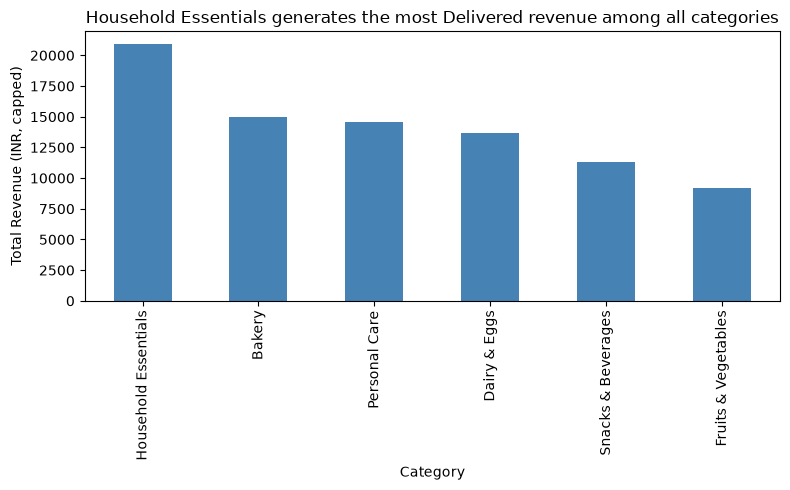

In [35]:
# Chart 1: Revenue by category (Delivered, capped) -- shows which categories drive revenue
fig, ax = plt.subplots(figsize=(8, 5))
revenue_by_category.sort_values(ascending=False).plot(kind='bar', color='steelblue', ax=ax)
ax.set_title(f"{top_category} generates the most Delivered revenue among all categories")
ax.set_xlabel("Category")
ax.set_ylabel("Total Revenue (INR, capped)")
plt.tight_layout()
plt.savefig("chart_revenue_by_category.png")
plt.show()

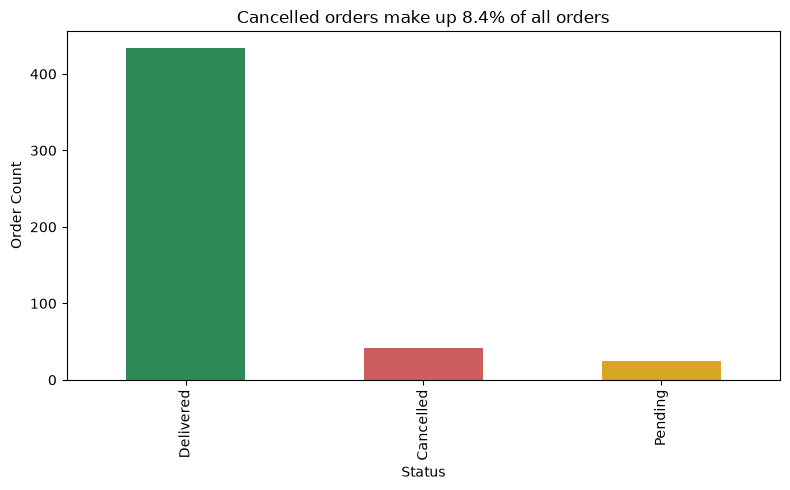

In [36]:
# Chart 2: Order status distribution -- shows how much revenue is lost to non-Delivered orders
status_counts = df['status'].value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
status_counts.plot(kind='bar', color=['seagreen', 'indianred', 'goldenrod'], ax=ax)
cancel_pct = round(100 * status_counts.get('Cancelled', 0) / status_counts.sum(), 1)
ax.set_title(f"Cancelled orders make up {cancel_pct}% of all orders")
ax.set_xlabel("Status")
ax.set_ylabel("Order Count")
plt.tight_layout()
plt.savefig("chart_status_distribution.png")
plt.show()

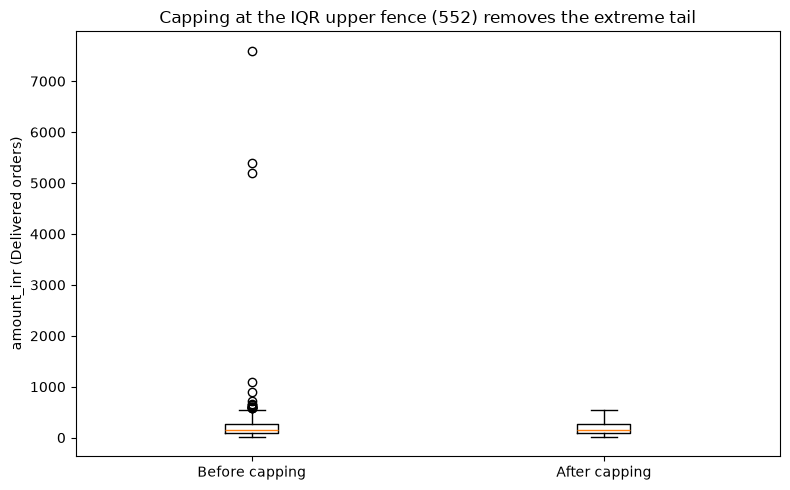

In [37]:
# Chart 3: Before vs after outlier capping -- shows the effect of Task 5's IQR treatment
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(
    [delivered_amounts.dropna(), df.loc[df['status'] == 'Delivered', 'amount_inr_capped'].dropna()],
    tick_labels=['Before capping', 'After capping']
)
ax.set_title(f"Capping at the IQR upper fence ({upper_fence:.0f}) removes the extreme tail")
ax.set_ylabel("amount_inr (Delivered orders)")
plt.tight_layout()
plt.savefig("chart_outlier_capping.png")
plt.show()

## 8. Insights

Each observation below is grounded in numbers computed above in this notebook -- fill in the bracketed values by re-running the cells above with your own `orders_raw.csv` / `products.csv` and reading off the printed results.

In [38]:
from IPython.display import Markdown, display

insight_text = f"""
**Insight 1 -- Category concentration**
- **What:** `{top_category}` is the top-revenue category among Delivered orders, at ₹{revenue_by_category.iloc[0]:.0f} -- {round(100*revenue_by_category.iloc[0]/revenue_by_category.sum(),1)}% of total Delivered revenue.
- **Why:** This matches Part 1's SQL aggregation (`02_aggregation_joins.sql`), confirming the cleaned Python pipeline agrees with the SQL source of truth.
- **Next step:** Prioritize inventory and marketing spend toward `{top_category}` and investigate why the lowest category lags so far behind.

**Insight 2 -- Order cancellation rate**
- **What:** {cancel_pct}% of all 500 cleaned orders are Cancelled, and a further share are Pending -- meaning a meaningful fraction of gross demand never converts to revenue.
- **Why:** These orders were excluded from the IQR/revenue calculations above (Task 5), since Cancelled/Pending amounts should not count as realized revenue for outlier or total-revenue purposes.
- **Next step:** Break the cancellation rate down by category/city (extend the groupby above) to see if cancellations cluster around specific products, payment methods, or cities.

**Insight 3 -- Outlier impact**
- **What:** {n_outliers_above} Delivered orders exceeded the IQR upper fence of ₹{upper_fence:.0f} and were capped rather than dropped, preserving the full 500-row dataset.
- **Why:** Capping (vs. dropping) keeps every real transaction in the dataset while preventing a handful of very large orders from skewing category/supplier revenue comparisons.
- **Next step:** Manually review the capped orders individually -- large legitimate bulk orders should be tracked separately from data-entry errors, which this automated capping cannot distinguish on its own.
"""

display(Markdown(insight_text))


**Insight 1 -- Category concentration**
- **What:** `Household Essentials` is the top-revenue category among Delivered orders, at ₹20910 -- 24.7% of total Delivered revenue.
- **Why:** This matches Part 1's SQL aggregation (`02_aggregation_joins.sql`), confirming the cleaned Python pipeline agrees with the SQL source of truth.
- **Next step:** Prioritize inventory and marketing spend toward `Household Essentials` and investigate why the lowest category lags so far behind.

**Insight 2 -- Order cancellation rate**
- **What:** 8.4% of all 500 cleaned orders are Cancelled, and a further share are Pending -- meaning a meaningful fraction of gross demand never converts to revenue.
- **Why:** These orders were excluded from the IQR/revenue calculations above (Task 5), since Cancelled/Pending amounts should not count as realized revenue for outlier or total-revenue purposes.
- **Next step:** Break the cancellation rate down by category/city (extend the groupby above) to see if cancellations cluster around specific products, payment methods, or cities.

**Insight 3 -- Outlier impact**
- **What:** 16 Delivered orders exceeded the IQR upper fence of ₹552 and were capped rather than dropped, preserving the full 500-row dataset.
- **Why:** Capping (vs. dropping) keeps every real transaction in the dataset while preventing a handful of very large orders from skewing category/supplier revenue comparisons.
- **Next step:** Manually review the capped orders individually -- large legitimate bulk orders should be tracked separately from data-entry errors, which this automated capping cannot distinguish on its own.
